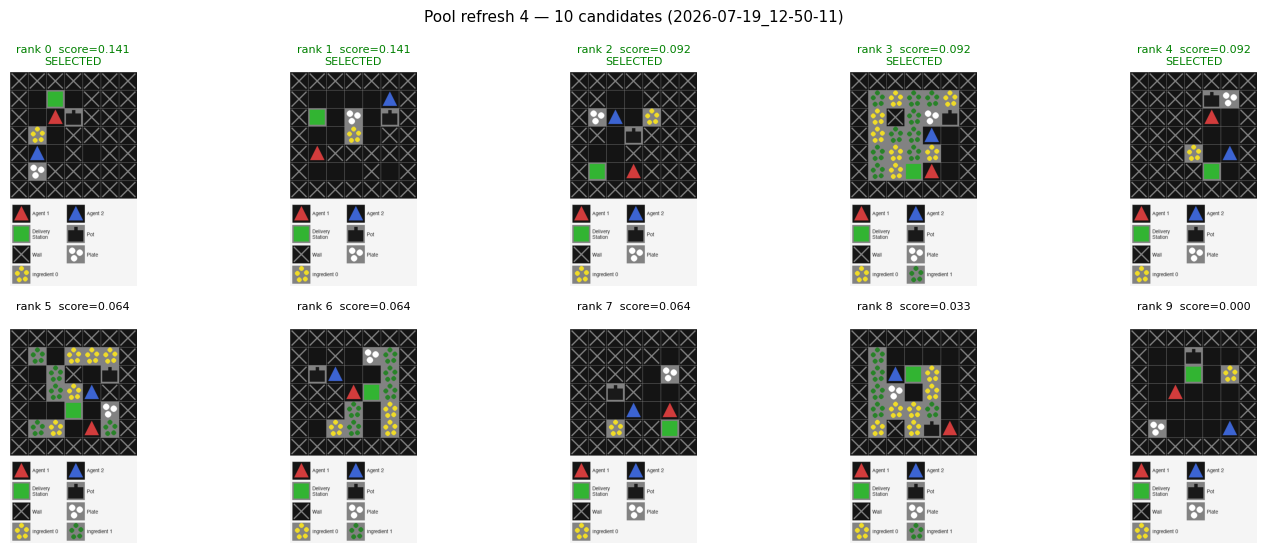

In [6]:
import sys, io, json, contextlib
import pickle, math, csv
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
# from config import render


OVERCOOKED_MA = Path("overcooked_MA").resolve()
if str(OVERCOOKED_MA) not in sys.path:
    sys.path.insert(0, str(OVERCOOKED_MA))
from environment.generator import LevelGenerator
from config import render_full_map

# Point this at the run whose pool_scores.csv you want to inspect.
run_dir = Path("/Users/katerynahamii/University/SoSe2026/Masterarbeit/MARL/marl_master_thesis/overcooked_MA/results/sfl/sfl_full_shaped_rich/2026-07-19_12-50-11")

with open(run_dir / "run_config.json") as f:
    run_cfg = json.load(f)
H, W = run_cfg["env_height"], run_cfg["env_width"]

pool_rows = list(csv.DictReader(open(run_dir / "pool_scores.csv")))
latest_refresh = max(int(r["refresh_id"]) for r in pool_rows)
pool_rows = [r for r in pool_rows if int(r["refresh_id"]) == latest_refresh]
pool_rows.sort(key=lambda r: int(r["rank"]))

# pool_scores.csv only stores the 4D UED vector (obs_density, obs_skew_x,
# res_density, res_skew_x), not the exact grid — calculate_element_coords()
# uses unseeded randomness for wall/resource placement, so this regenerates
# A layout with the same macro parameters, not necessarily pixel-identical
# to what was actually scored during training.
gen = LevelGenerator(height=H, width=W)
entries = []
with contextlib.redirect_stdout(io.StringIO()):  # silence generator's per-level prints
    for row in pool_rows:
        elems = gen.create_level_elements(
            float(row["obs_density"]), float(row["obs_skew_x"]),
            float(row["res_density"]), float(row["res_skew_x"]),
        )
        grid = gen.calculate_element_coords(elems)
        entries.append((grid, row))
        print("entries", entries)

ncols = 5
nrows = math.ceil(len(entries) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.8))
axes = np.array(axes).reshape(-1)

for ax, (grid, row) in zip(axes, entries):
    img = render_full_map(grid, tile_size=48)
    ax.imshow(img)
    selected = row["selected"] == "True"
    ax.set_title(
        f"rank {row['rank']}  score={float(row['score']):.3f}\n{'SELECTED' if selected else ''}",
        fontsize=8, color="green" if selected else "black",
    )
    ax.axis("off")

for ax in axes[len(entries):]:
    ax.axis("off")

plt.suptitle(f"Pool refresh {latest_refresh} — {len(entries)} candidates ({run_dir.name})", fontsize=11)
plt.tight_layout()
plt.show()
